# News Categorization

In [1]:
# Load Dataset

In [1]:
import numpy as np

import pandas as pd

df = pd.read_csv('../data/bbc-news-data.csv', sep="\t")

df


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...
...,...,...,...,...
2220,tech,397.txt,BT program to beat dialler scams,BT is introducing two initiatives to help bea...
2221,tech,398.txt,Spam e-mails tempt net shoppers,Computer users across the world continue to i...
2222,tech,399.txt,Be careful how you code,A new European directive could put software w...
2223,tech,400.txt,US cyber security chief resigns,The man making sure US computer networks are ...


In [2]:
# check any empty values exist

In [3]:
df.isna().sum()

category    0
filename    0
title       0
content     0
dtype: int64

In [4]:
# Check any duplicates exist

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# Assuming your columns are named 'text' and 'category'

In [7]:
X = df['content']
y = df['category']

In [8]:
X

0        Quarterly profits at US media giant TimeWarne...
1        The dollar has hit its highest level against ...
2        The owners of embattled Russian oil giant Yuk...
3        British Airways has blamed high fuel prices f...
4        Shares in UK drinks and food firm Allied Dome...
                              ...                        
2220     BT is introducing two initiatives to help bea...
2221     Computer users across the world continue to i...
2222     A new European directive could put software w...
2223     The man making sure US computer networks are ...
2224     Online role playing games are time-consuming,...
Name: content, Length: 2225, dtype: str

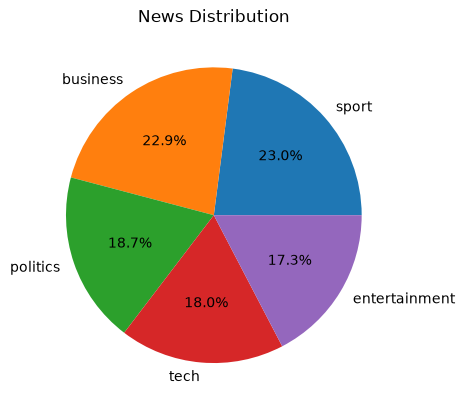

In [21]:
import matplotlib.pyplot as plt


y.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('News Distribution')
plt.ylabel('')
plt.show()

In [22]:
# Load some modules

In [23]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer


In [24]:
# Vectorize text using TF-IDF

In [25]:
vectorizer = TfidfVectorizer(
    stop_words="english",# Remove common words (the, is, in)
    max_features=5000,# Keep top 5,000 most relevant features
    ngram_range=(1,2) # Include unigrams (single words) & bigrams (pairs of words)
)

In [26]:
# Fit on training data, transform both train and test

In [27]:
X_vec = vectorizer.fit_transform(X)

X_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 263249 stored elements and shape (2225, 5000)>

In [28]:
# Choose the best k

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Define range of K values to test (e.g., K = 2 to 10)
k_range = range(2, 11)
inertias = []
silhouette_scores = []

# 2. Iterate through each K and compute metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_vec)
    
    # Store Inertia (Elbow Method)
    inertias.append(kmeans.inertia_)
    
    # Store Silhouette Score
    score = silhouette_score(X_vec, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K = {k} | Silhouette Score: {score:.4f} | Inertia: {kmeans.inertia_:.2f}")

K = 2 | Silhouette Score: 0.0084 | Inertia: 2137.91
K = 3 | Silhouette Score: 0.0128 | Inertia: 2117.63
K = 4 | Silhouette Score: 0.0132 | Inertia: 2107.01
K = 5 | Silhouette Score: 0.0149 | Inertia: 2086.44
K = 6 | Silhouette Score: 0.0158 | Inertia: 2073.77
K = 7 | Silhouette Score: 0.0173 | Inertia: 2063.95
K = 8 | Silhouette Score: 0.0173 | Inertia: 2056.58
K = 9 | Silhouette Score: 0.0169 | Inertia: 2045.22
K = 10 | Silhouette Score: 0.0170 | Inertia: 2037.88


In [54]:
# Cluster the vectorized representation using vectorized K-Means

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10,random_state=42,init='k-means++')

df['cluster'] = kmeans.fit_predict(X_vec)

In [32]:
df.groupby('cluster')[['category','title']].head()

,category,title
0,business,Ad sales boost Time Warner profit
1,business,Dollar gains on Greenspan speech
2,business,Yukos unit buyer faces loan claim
3,business,High fuel prices hit BA's profits
4,business,Pernod takeover talk lifts Domecq
5,business,Japan narrowly escapes recession
6,business,Jobs growth still slow in the US
7,business,India calls for fair trade rules
8,business,Ethiopia's crop production up 24%
9,business,Court rejects $280bn tobacco case


In [33]:
for cluster_id, group in df.groupby('cluster'):
    print(f"\n=== CLUSTER {cluster_id} ===")
    print(group[['category', 'title']].head(5).to_string(index=False))


=== CLUSTER 0 ===
     category                             title
entertainment  Musical treatment for Capra film
entertainment Richard and Judy choose top books
entertainment Poppins musical gets flying start
entertainment Bennett play takes theatre prizes
entertainment   Levy tipped for Whitbread prize

=== CLUSTER 1 ===
category                            title
   sport Smith keen on Home series return
   sport Republic to face China and Italy
   sport  Finnan says Irish can win group
   sport      Irish finish with home game
   sport  Hodgson shoulders England blame

=== CLUSTER 2 ===
category                             title
business Ad sales boost Time Warner profit
business High fuel prices hit BA's profits
business Pernod takeover talk lifts Domecq
business  India calls for fair trade rules
business Ethiopia's crop production up 24%

=== CLUSTER 3 ===
category                             title
business Call centre users 'lose patience'
business Brussels raps mobile call charg

In [34]:
# Create a confusion-style matrix between clusters and real categories
ct = pd.crosstab(df['cluster'], df['category'])
print(ct)

category  business  entertainment  politics  sport  tech
cluster                                                 
0                0            190         0      0     2
1                0              0         0    136     0
2              312              2        10      1     5
3                5              0         3      0   110
4              125              0         0      0     0
5               18             13       263      0     9
6               36              0         0      0     0
7                2              0       139      0     0
8                1              1         0    374     2
9               11            180         2      0   273


In [37]:
# 1. Define your semantic mapping dictionary based on cluster inspection
cluster_names = {
    0: "Arts & Literature",
    1: "International Football & Qualifiers",
    2: "Corporate Finance & Global Trade",
    3: "Telecommunications & Regulation",
    4: "Macroeconomics & Central Banking",
    5: "Corporate Litigation & Policy",
    6: "Yukos Bankruptcy & Corporate Trials",
    7: "UK Politics & Fiscal Policy",
    8: "Athletics & General Sports",
    9: "Tech Fraud & Digital Media"
}

# 2. Map cluster IDs to a new column in your DataFrame
df['cluster_label'] = df['cluster'].map(cluster_names)

# 3. View the mapped output
df.groupby('cluster_label')['content']


In [41]:
for cluster_name, group in df.groupby('cluster_label')[['title', 'content']]:
    print(f"\n==========================================")
    print(f"📌 CATEGORY: {cluster_name.upper()} (Total: {len(group)} articles)")
    print(f"==========================================")
    
    # Show first 3 articles in this cluster
    for idx, row in group.head(3).iterrows():
        print(f"\n📰 Title: {row['title']}")
        # Print first 150 characters of the content snippet
        snippet = str(row['content'])[:150].replace('\n', ' ')
        print(f"   Content: {snippet}...")


📌 CATEGORY: ARTS & LITERATURE (Total: 192 articles)

📰 Title: Musical treatment for Capra film
   Content:  The classic film It's A Wonderful Life is to be turned into a musical by the producer of the controversial hit show Jerry Springer - The Opera.  Fran...

📰 Title: Richard and Judy choose top books
   Content:  The 10 authors shortlisted for a Richard and Judy book award in 2005 are hoping for a boost in sales following the success of this year's winner.  Th...

📰 Title: Poppins musical gets flying start
   Content:  The stage adaptation of children's film Mary Poppins has had its opening night in London's West End.  Sir Cameron Mackintosh's lavish production, whi...

📌 CATEGORY: ATHLETICS & GENERAL SPORTS (Total: 378 articles)

📰 Title: Arsenal 'may seek full share listing'
   Content:  Arsenal vice-chairman David Dein has said the club may consider seeking a full listing for its shares on the London Stock Exchange.  Speaking at the ...

📰 Title: Holmes wins '2004 top TV moment'

In [39]:
# Save Model

In [40]:
import os
import joblib

# Define the directory path (e.g., '../models' or '../../models')
# Using os.path.join with '..' ensures it targets the folder outside the current directory
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "models"))

# Create the directory if it doesn't exist
os.makedirs(models_dir, exist_ok=True)

# Define file paths
kmeans_path = os.path.join(models_dir, "kmeans.pkl")
vectorizer_path = os.path.join(models_dir, "vectorizer.pkl")

# Save the models using joblib (recommended for scikit-learn models)
joblib.dump(kmeans, kmeans_path)
joblib.dump(vectorizer, vectorizer_path)

print(f"Saved kmeans model to: {kmeans_path}")
print(f"Saved vectorizer to: {vectorizer_path}")

Saved kmeans model to: C:\Users\admin\news-clustering\models\kmeans.pkl
Saved vectorizer to: C:\Users\admin\news-clustering\models\vectorizer.pkl
